In [5]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

play = pd.read_csv("Play Store Data.csv")

In [7]:
play = play.drop_duplicates(subset="App")
play = play.reset_index(drop=True)
play = play[play["Category"] != "1.9"]

In [9]:
play["Rating"] = pd.to_numeric(play["Rating"], errors="coerce")
play["Reviews"] = pd.to_numeric(play["Reviews"], errors="coerce")

play["Installs"] = (
    play["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

play["Installs"] = pd.to_numeric(play["Installs"], errors="coerce")

In [11]:
play["Price"] = (
    play["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

play["Price"] = pd.to_numeric(
    play["Price"],
    errors="coerce"
)

In [13]:
play["Revenue"] = play["Price"] * play["Installs"]

In [15]:
def convert_size(size):

    if isinstance(size, str):

        if "M" in size:
            return float(size.replace("M",""))

        elif "k" in size:
            return float(size.replace("k",""))/1024

    return np.nan

play["Size_MB"] = play["Size"].apply(convert_size)

In [17]:
play["Android"] = (
    play["Android Ver"]
    .str.extract(r'(\d+\.\d+)')
)

play["Android"] = pd.to_numeric(
    play["Android"],
    errors="coerce"
)

In [20]:
df = play[
    play["Installs"] >= 10000
]
df = df[
    df["Revenue"] >= 10000
]

In [22]:
df = df[
    df["Android"] > 4.0
]

In [24]:
df = df[
    df["Size_MB"] > 15
]

In [26]:
df = df[
    df["Content Rating"] == "Everyone"
]

In [28]:
df = df[
    df["App"].str.len() <= 30
]

In [30]:
top3 = (
    df.groupby("Category")["Installs"]
      .sum()
      .nlargest(3)
      .index
)

In [32]:
df = df[
    df["Category"].isin(top3)
]

In [34]:
summary = (
    df.groupby(["Category","Type"])
      .agg({
          "Installs":"mean",
          "Revenue":"mean"
      })
      .reset_index()
)

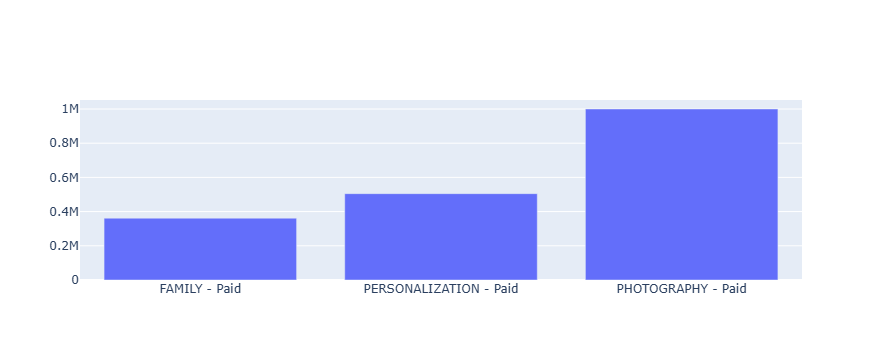

In [37]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=summary["Category"] + " - " + summary["Type"],
        y=summary["Installs"],
        name="Average Installs",
        yaxis="y1"
    )
)

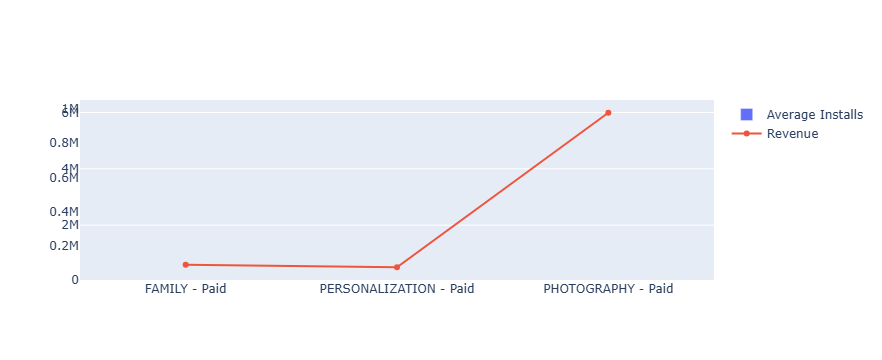

In [38]:
fig.add_trace(
    go.Scatter(
        x=summary["Category"] + " - " + summary["Type"],
        y=summary["Revenue"],
        mode="lines+markers",
        name="Revenue",
        yaxis="y2"
    )
)

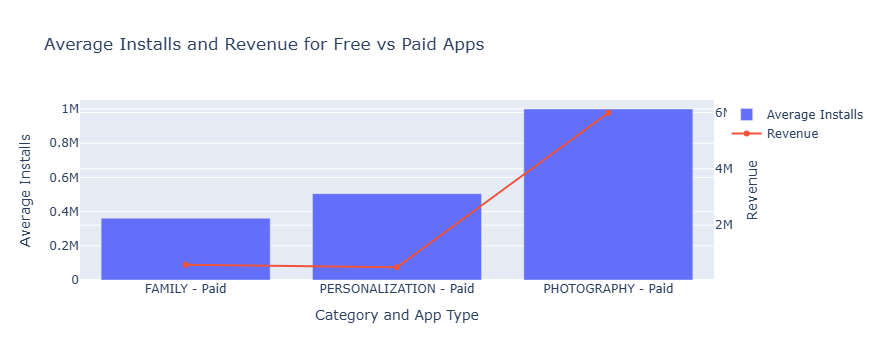

In [39]:
fig.update_layout(

    title="Average Installs and Revenue for Free vs Paid Apps",

    xaxis_title="Category and App Type",

    yaxis=dict(
        title="Average Installs"
    ),

    yaxis2=dict(
        title="Revenue",
        overlaying="y",
        side="right"
    )

)

In [42]:
from datetime import datetime
import pytz

india = pytz.timezone("Asia/Kolkata")
now = datetime.now(india)

if 13 <= now.hour < 14:

    fig.show()

else:

    print(
        "This graph is available only between "
        "1 PM IST and 2 PM IST."
    )

This graph is available only between 1 PM IST and 2 PM IST.


In [45]:
fig.write_html(
    "task6_dual_axis_dashboard.html",
    include_plotlyjs="cdn"
)